# 02. Gurobi ground truth 와 Benders

확인 항목:
1. Original CFLP + Gurobi
2. Benders + Gurobi
3. objective 및 `y` 비교
4. primal/dual SP objective 비교
5. iteration 별 cut 과 MP snapshot 저장
6. LB/UB convergence figure

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd

from cflp_bd_qa_ex2.config.loader import load_config

cfg = load_config(ROOT / "config" / "experiments" / "pilot.yaml")
print("configuration_hash:", cfg["configuration_hash"][:16])


configuration_hash: 0dc9f18b09b09302


## 0. Gurobi preflight

"이 환경에는 라이선스가 없다" 고 정적으로 단정하지 않는다. 실행 시점에 확인한다.

제한(size-limited) 라이선스는 선형 모델 2,000 변수와 **이차항 모델 200 변수** 한계를 갖는다.

In [2]:
from cflp_bd_qa_ex2.solvers.gurobi import check_gurobi_available, probe_size_limits

available, status, message = check_gurobi_available()
print("available :", available)
print("status    :", status)
print("message   :", message)
print("size limit:", probe_size_limits())


available : True
status    : None
message   : gurobi (13, 0, 3)
size limit: {'linear_limit': None, 'quadratic_limit': None, 'restricted': False}


## 1. Original CFLP (ground truth)

`OPTIMAL` 인 경우에만 `objective_opt` 로 취급한다.
Time limit 으로 얻은 incumbent 는 ground truth 라고 부르지 않는다.

파일럿의 최대 크기 25x50 은 SP 의 `x_ij` 가 1250개로 제한 라이선스의
선형 2000 변수 한계 안에 들어온다. 따라서 모든 인스턴스를 제한 라이선스에서도 풀 수 있다.

(참고: 이전 명세의 32x100 은 SP 의 `x_ij` 가 3200개라 Original 뿐 아니라 **SP 부터** 실패했다.)

In [3]:
from cflp_bd_qa_ex2.data.io import load_all_instances
from cflp_bd_qa_ex2.models.cflp import solve_original_cflp
from cflp_bd_qa_ex2.status import Status

instances = load_all_instances(ROOT / "data" / "raw")

gt_rows = []
ground_truth = {}
for inst in instances:
    outcome = solve_original_cflp(inst, cfg)
    ground_truth[inst.instance_id] = outcome
    gt_rows.append({
        "instance_id": inst.instance_id,
        "status": str(outcome.status),
        "objective_opt": outcome.objective if outcome.status is Status.OPTIMAL else None,
        "runtime": outcome.runtime,
    })

gt = pd.DataFrame(gt_rows)
gt


,instance_id,status,objective_opt,runtime
0,16x50_s300,OPTIMAL,16931.156496,0.049618
1,16x50_s301,OPTIMAL,14807.168967,0.011978
2,16x50_s302,OPTIMAL,16288.163568,0.032054
3,16x50_s303,OPTIMAL,17545.228096,0.032389
4,16x50_s304,OPTIMAL,16518.020590,0.038767
5,25x50_s400,OPTIMAL,18195.487510,0.064344
6,25x50_s401,OPTIMAL,20018.769130,0.049868
7,25x50_s402,OPTIMAL,19002.622851,0.047955
8,25x50_s403,OPTIMAL,18810.407110,0.041152
9,25x50_s404,OPTIMAL,18682.672429,0.058962


## 2. Benders + Gurobi

MP 와 SP 를 모두 Gurobi 로 풀어 Original CFLP 결과와 비교한다.
`--encoded-mp` 상당의 옵션으로 매 iteration encoded MP 도 함께 푼다.

In [4]:
from cflp_bd_qa_ex2.benders.solver import GurobiMasterProvider, run_benders

traces = {}
run_rows = []
for inst in instances:
    trace = run_benders(inst, GurobiMasterProvider(), cfg, solve_encoded_each_iteration=True)
    traces[inst.instance_id] = trace
    record = trace.run.as_record()
    gt_outcome = ground_truth[inst.instance_id]
    record["ground_truth_objective"] = (
        gt_outcome.objective if gt_outcome.status is Status.OPTIMAL else None
    )
    run_rows.append(record)

runs = pd.DataFrame(run_rows)
runs[["instance_id", "termination_status", "benders_iterations",
      "certified_lower_bound", "best_upper_bound", "ground_truth_objective",
      "dual_minimality_status", "dual_guard_action"]]


,instance_id,termination_status,benders_iterations,certified_lower_bound,best_upper_bound,ground_truth_objective,dual_minimality_status,dual_guard_action
0,16x50_s300,OPTIMAL,5,16931.156496,16931.156496,16931.156496,MINIMAL,NONE
1,16x50_s301,OPTIMAL,4,14807.168967,14807.168967,14807.168967,MINIMAL,NONE
2,16x50_s302,OPTIMAL,10,16288.163568,16288.163568,16288.163568,MINIMAL,NONE
3,16x50_s303,OPTIMAL,4,17545.228096,17545.228096,17545.228096,MINIMAL,NONE
4,16x50_s304,OPTIMAL,9,16518.020590,16518.020590,16518.020590,MINIMAL,NONE
5,25x50_s400,OPTIMAL,10,18195.487510,18195.487510,18195.487510,MINIMAL,NONE
6,25x50_s401,OPTIMAL,4,20018.769130,20018.769130,20018.769130,MINIMAL,NONE
7,25x50_s402,OPTIMAL,12,19001.550949,19002.622851,19002.622851,MINIMAL,NONE
8,25x50_s403,OPTIMAL,5,18810.407110,18810.407110,18810.407110,MINIMAL,NONE
9,25x50_s404,OPTIMAL,9,18682.672429,18682.672429,18682.672429,MINIMAL,NONE


## 3. Objective 와 `y` 비교

작은 인스턴스에서 `Obj_Original ~= Obj_Benders` 를 확인한다.

In [5]:
comparison = runs.dropna(subset=["ground_truth_objective"]).copy()
comparison["abs_diff"] = (
    comparison["best_upper_bound"] - comparison["ground_truth_objective"]
).abs()

print("최대 절대 오차: %.3e" % comparison["abs_diff"].max())

y_match = []
for _, row in comparison.iterrows():
    gt_y = ground_truth[row["instance_id"]].payload.get("y")
    y_match.append({
        "instance_id": row["instance_id"],
        "benders_y": row["best_y"],
        "original_y": gt_y,
        "same_y": list(row["best_y"]) == list(gt_y),
        "abs_diff": row["abs_diff"],
    })

pd.DataFrame(y_match)


최대 절대 오차: 7.276e-12


,instance_id,benders_y,original_y,same_y,abs_diff
0,16x50_s300,"[0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0]","[0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0]",True,0.000000e+00
1,16x50_s301,"[0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1]","[0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1]",True,3.637979e-12
2,16x50_s302,"[1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1]","[1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1]",True,1.818989e-12
3,16x50_s303,"[0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1]","[0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1]",True,3.637979e-12
4,16x50_s304,"[1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0]","[1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0]",True,0.000000e+00
5,25x50_s400,"[0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, ...","[0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, ...",True,3.637979e-12
6,25x50_s401,"[1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, ...","[1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, ...",True,0.000000e+00
7,25x50_s402,"[1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, ...","[1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, ...",True,7.275958e-12
8,25x50_s403,"[1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...","[1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, ...",True,0.000000e+00
9,25x50_s404,"[0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, ...","[0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, ...",True,0.000000e+00


`y` 가 달라도 objective 가 같을 수 있다. CFLP 는 대체 최적해를 가질 수 있으므로
objective 일치가 1차 기준이고 `y` 일치는 참고값이다.

## 4. SP primal / dual objective 비교 (strong duality)

`sum_i u_i - sum_j s_j ybar_j v_j` 가 primal 최적값과 같아야 한다.
또한 dual constraint `u_i - d_i v_j <= d_i c_ij` 가 만족되어야 한다.

동시에 **dual minimality guard** 결과도 확인한다. 닫힌 시설의 `v_j` 는 optimal face
위에서 팽창할 수 있으므로, 이것이 실제로 일어나는지 본다.

In [6]:
from cflp_bd_qa_ex2.models.subproblem import check_dual_minimality, solve_subproblem

duality_rows = []
for inst in instances:
    if ground_truth[inst.instance_id].status is not Status.OPTIMAL:
        continue
    y = np.asarray(ground_truth[inst.instance_id].payload["y"], dtype=int)
    outcome, dual = solve_subproblem(inst, y, cfg)
    if dual is None:
        continue
    guard = cfg["benders"]["dual_minimality_guard"]
    dual = check_dual_minimality(dual, y, float(guard["atol"]), float(guard["rtol"]))
    duality_rows.append({
        "instance_id": inst.instance_id,
        "primal": dual.primal_objective,
        "dual": dual.dual_objective,
        "strong_duality_gap": dual.strong_duality_gap,
        "dual_constraint_violation": dual.dual_constraint_max_violation,
        "dual_minimality_status": str(dual.minimality_status),
        "v_gap_open": dual.v_minimality_open_gap,
        "v_gap_closed": dual.v_minimality_closed_gap,
    })

duality = pd.DataFrame(duality_rows)
duality


,instance_id,primal,dual,strong_duality_gap,dual_constraint_violation,dual_minimality_status,v_gap_open,v_gap_closed
0,16x50_s300,3516.317612,3516.317612,4.547474e-13,2.842171e-14,MINIMAL,8.881784e-16,4.440892e-16
1,16x50_s301,2971.793071,2971.793071,4.547474e-13,1.421085e-14,MINIMAL,4.440892e-16,0.000000e+00
2,16x50_s302,3680.956382,3680.956382,4.547474e-13,2.842171e-14,MINIMAL,8.881784e-16,8.881784e-16
3,16x50_s303,4862.338627,4862.338627,9.094947e-13,2.842171e-14,MINIMAL,8.881784e-16,8.881784e-16
4,16x50_s304,4870.761236,4870.761236,0.000000e+00,2.842171e-14,MINIMAL,8.881784e-16,8.881784e-16
5,25x50_s400,3342.805182,3342.805182,4.547474e-13,3.552714e-14,MINIMAL,8.881784e-16,8.881784e-16
6,25x50_s401,4240.029788,4240.029788,2.728484e-12,7.815970e-14,MINIMAL,1.776357e-15,2.220446e-16
7,25x50_s402,3624.548004,3624.548004,1.818989e-12,3.375078e-14,MINIMAL,8.881784e-16,8.881784e-16
8,25x50_s403,3960.900772,3960.900772,9.094947e-13,5.684342e-14,MINIMAL,8.881784e-16,0.000000e+00
9,25x50_s404,3864.849559,3864.849559,9.094947e-13,2.842171e-14,MINIMAL,8.881784e-16,8.881784e-16


## 5. Iteration 별 cut 과 MP snapshot 저장

In [7]:
from cflp_bd_qa_ex2.evaluation.results import attach_provenance, save_records

iteration_records, cut_records = [], []
for trace in traces.values():
    iteration_records.extend(it.as_record() for it in trace.iterations)
    cut_records.extend(trace.cut_snapshots)

formats = cfg["output"]["formats"]
save_records(attach_provenance(iteration_records, cfg), ROOT / "results" / "benders",
             "benders_iterations", formats,
             merge_keys=("instance_id", "trajectory_source", "benders_iteration"))
save_records(attach_provenance(run_rows, cfg), ROOT / "results" / "benders",
             "benders_runs", formats, merge_keys=("instance_id", "trajectory_source"))
save_records(attach_provenance(cut_records, cfg), ROOT / "results" / "benders",
             "cut_trajectory", formats,
             merge_keys=("instance_id", "trajectory_source", "benders_iteration", "cut_index"))

iterations = pd.DataFrame(iteration_records)
print(f"iteration 기록 {len(iterations)}행, cut 기록 {len(cut_records)}행 저장")


iteration 기록 104행, cut 기록 104행 저장


## 6. LB / UB convergence figure

LB 는 단조 증가해야 하고 항상 UB 이하여야 한다.

In [8]:
from cflp_bd_qa_ex2.evaluation.plots import plot_bound_trajectory

figures = ROOT / "results" / "figures"
bound_figures = []
targets = [i.instance_id for i in instances if i.name in ("4x12", "8x25", "16x50")][:3]
for instance_id in targets:
    # suffix=True 로 인스턴스별 파일을 만든다 (덮어쓰기 방지).
    path = plot_bound_trajectory(iterations, figures, instance_id, suffix=True)
    bound_figures.append(path)
    print(path)


c:\Users\User\Desktop\KMJ\Study\Quantum\cflp-bd-qa-ex2\results\figures\fig03_bound_trajectory_16x50_s300.png
c:\Users\User\Desktop\KMJ\Study\Quantum\cflp-bd-qa-ex2\results\figures\fig03_bound_trajectory_16x50_s301.png
c:\Users\User\Desktop\KMJ\Study\Quantum\cflp-bd-qa-ex2\results\figures\fig03_bound_trajectory_16x50_s302.png


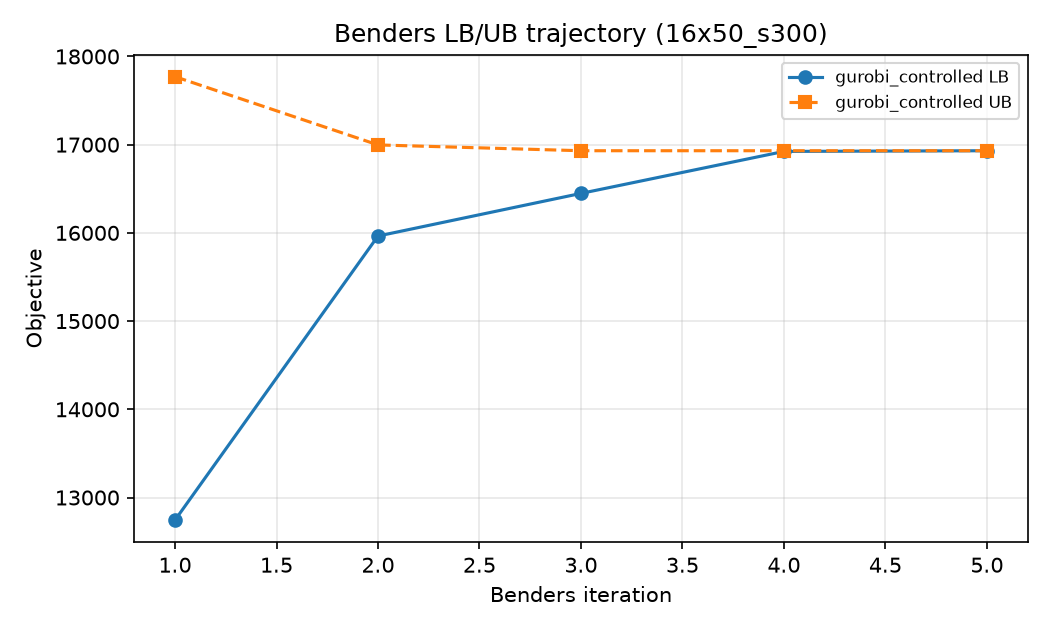

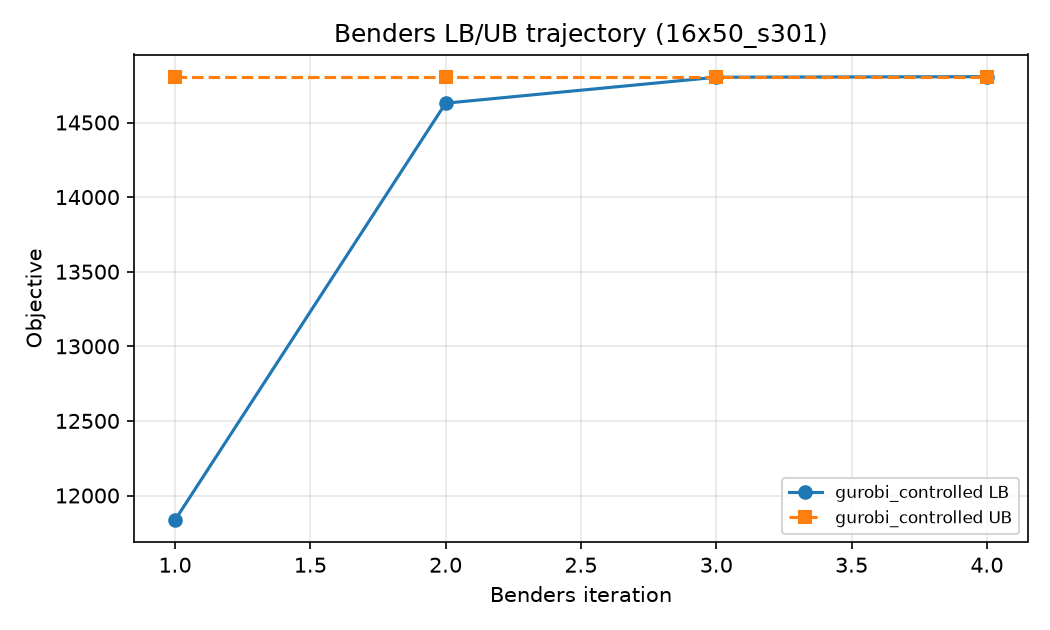

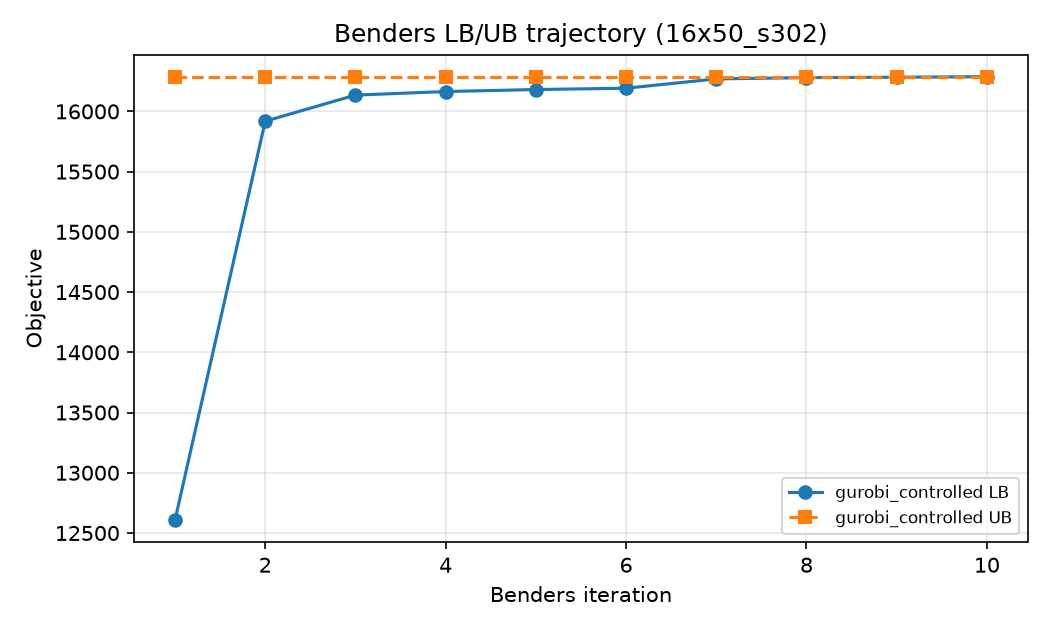

In [9]:
from IPython.display import Image, display

# 방금 생성한 경로만 연다. 고정 이름 파일은 notebook 06 에서 생성되므로
# 깨끗한 결과 폴더에서 이 notebook 만 실행하면 존재하지 않는다.
for path in bound_figures:
    display(Image(filename=str(path)))


## 해석

- Benders + Gurobi 의 목적값이 Original CFLP 와 기계 정밀도 수준에서 일치하면
  formulation, dual 부호 규약, cut 방향이 모두 맞다는 뜻이다.
- strong duality gap 이 0 에 가깝고 dual constraint 위반이 없으면 dual 추출이 정확하다.
- `v_gap_open` 이 0 인 것은 필연이다. 열린 시설에서 `v_j` 를 더 낮추면 dual objective 가
  primal 최적값을 넘게 되어 모순이기 때문이다.
  반면 `v_gap_closed` 가 0 인 것은 **Gurobi dual simplex 의 구현 특성**이며
  수학적 보장이 아니다. 그래서 guard 를 둔다.
- SP 가 라이선스 한계를 넘는 크기가 있으면 `GUROBI_SIZE_LIMIT` 으로 남는다.
  그 행을 삭제하지 않는다. 현재 파일럿(최대 25x50)에서는 발생하지 않는다.